In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.model_selection import ParameterSampler
import gymnasium as gym
from gymnasium.spaces import Discrete, MultiDiscrete

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor
from stable_baselines3.common.evaluation import evaluate_policy

from industrial_inventory_env import (
    IndustrialInventoryEnv,
    generate_student_config,
)

# 1. Environment & Config Setup
ROLL_NUMBER = "DA25M622"
student_config = generate_student_config(ROLL_NUMBER)
print(f"Student Config: {student_config}")

Student Config: {'project_version': 'IITM-6002W-RL-Inventory-2026-v1', 'roll_number': 'DA25M622', 'variant_id': 'V022', 'demand_multiplier_profile': [1.0, 1.1, 0.9], 'initial_inventory_profile': [110, 100, 90], 'lead_time_delay_profile': [0.1, 0.0, 0.05], 'declared_ranges': {'demand_multiplier': [0.85, 1.15], 'initial_inventory': [80, 120], 'lead_time_delay_probability': [0.0, 0.1]}, 'config_fingerprint': '7d77fc79debf206a'}


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
class FlattenMultiDiscreteActionWrapper(gym.ActionWrapper):
    """Maps MultiDiscrete([11, 11, 11]) to Discrete(1331)."""
    def __init__(self, env: gym.Env):
        super().__init__(env)
        self.nvec = env.action_space.nvec
        self.action_space = Discrete(int(np.prod(self.nvec)))

    def action(self, action: int) -> np.ndarray:
        multi_action = np.unravel_index(action, self.nvec)
        return np.array(multi_action, dtype=self.env.action_space.dtype)

def make_env_fn(seed=None):
    return FlattenMultiDiscreteActionWrapper(
        IndustrialInventoryEnv(
            student_config=student_config,
            scenario_mode="random",
            domain_randomization=True,
        )
    )

class DoubleDQN(DQN):
    def train(self, gradient_steps: int, batch_size: int = 100) -> None:
        self.policy.set_training_mode(True)
        self._update_learning_rate(self.policy.optimizer)

        losses = []
        for _ in range(gradient_steps):
            replay_data = self.replay_buffer.sample(batch_size, env=self._vec_normalize_env)
            discounts = replay_data.discounts if replay_data.discounts is not None else self.gamma

            with torch.no_grad():
                next_actions = self.q_net(replay_data.next_observations).argmax(dim=1, keepdim=True)
                next_q_values = self.q_net_target(replay_data.next_observations).gather(1, next_actions)
                next_q_values = next_q_values.reshape(-1, 1)
                target_q_values = replay_data.rewards + (1 - replay_data.dones) * discounts * next_q_values

            current_q_values = self.q_net(replay_data.observations)
            current_q_values = torch.gather(current_q_values, dim=1, index=replay_data.actions.long())

            loss = F.smooth_l1_loss(current_q_values, target_q_values)
            losses.append(loss.item())

            self.policy.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.policy.parameters(), self.max_grad_norm)
            self.policy.optimizer.step()

        self._n_updates += gradient_steps
        self.logger.record("train/n_updates", self._n_updates, exclude="tensorboard")
        self.logger.record("train/loss", np.mean(losses))

In [3]:
param_distributions = {
    "learning_rate": [5e-5, 1e-4, 3e-4, 5e-4],
    "batch_size": [64, 128, 256],
    "buffer_size": [50000, 100000],
    "learning_starts": [500, 1000, 2000],
    "train_freq": [1, 4],
    "gradient_steps": [1, 2],
    "target_update_interval": [500, 1000, 2000],
    "exploration_fraction": [0.25, 0.40, 0.50],
    "exploration_final_eps": [0.02, 0.05, 0.10],
    "gamma": [0.95, 0.98, 0.99],
    "net_arch": [[128, 128], [256, 256], [256, 128]],
}

N_TRIALS = 8
BUDGET_TIMESTEPS = 30000  # Timesteps per trial evaluation
N_EVAL_EPISODES = 5

sampler = ParameterSampler(param_distributions, n_iter=N_TRIALS, random_state=2026)

tuning_results = []
best_cost = float("inf")
best_params = None

print(f"Starting Hyperparameter Search across {N_TRIALS} candidates...")

for trial_idx, params in enumerate(sampler):
    print(f"\n--- Running Trial {trial_idx + 1}/{N_TRIALS} ---")
    print(params)

    # Separate policy architecture from algorithm kwargs
    policy_kwargs = dict(net_arch=params["net_arch"])
    
    train_vec_env = VecMonitor(make_vec_env(make_env_fn, n_envs=4, seed=2026 + trial_idx))
    eval_vec_env = VecMonitor(make_vec_env(make_env_fn, n_envs=1, seed=9999))

    model = DoubleDQN(
        policy="MultiInputPolicy",
        env=train_vec_env,
        learning_rate=params["learning_rate"],
        batch_size=params["batch_size"],
        buffer_size=params["buffer_size"],
        learning_starts=params["learning_starts"],
        train_freq=params["train_freq"],
        gradient_steps=params["gradient_steps"],
        target_update_interval=params["target_update_interval"],
        exploration_fraction=params["exploration_fraction"],
        exploration_final_eps=params["exploration_final_eps"],
        gamma=params["gamma"],
        policy_kwargs=policy_kwargs,
        verbose=0,
    )

    # Train trial candidate
    model.learn(total_timesteps=BUDGET_TIMESTEPS)

    # Evaluate mean reward (Reward in env is -daily_cost / 100)
    mean_reward, std_reward = evaluate_policy(
        model, eval_vec_env, n_eval_episodes=N_EVAL_EPISODES, deterministic=True
    )
    
    # Convert episode return back to raw episode cost
    # Episode return = - (Episode Cost / 100) => Cost = -mean_reward * 100
    mean_cost = -mean_reward * 100.0

    print(f"Trial {trial_idx + 1} Result -> Mean Cost: {mean_cost:,.2f} (Std: {std_reward * 100:,.2f})")

    tuning_results.append({
        "trial": trial_idx + 1,
        "mean_cost": mean_cost,
        "mean_reward": mean_reward,
        **params
    })

    if mean_cost < best_cost:
        best_cost = mean_cost
        best_params = params
        model.save("best_tuned_double_dqn.zip")

    train_vec_env.close()
    eval_vec_env.close()

Starting Hyperparameter Search across 8 candidates...

--- Running Trial 1/8 ---
{'train_freq': 4, 'target_update_interval': 2000, 'net_arch': [256, 128], 'learning_starts': 500, 'learning_rate': 5e-05, 'gradient_steps': 1, 'gamma': 0.98, 'exploration_fraction': 0.4, 'exploration_final_eps': 0.1, 'buffer_size': 100000, 'batch_size': 256}


/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Trial 1 Result -> Mean Cost: 522,447.50 (Std: 38,178.32)

--- Running Trial 2/8 ---
{'train_freq': 1, 'target_update_interval': 2000, 'net_arch': [128, 128], 'learning_starts': 500, 'learning_rate': 0.0005, 'gradient_steps': 1, 'gamma': 0.99, 'exploration_fraction': 0.25, 'exploration_final_eps': 0.1, 'buffer_size': 50000, 'batch_size': 128}


/home/sohang/Projects/iit-madras-web-mtech-ai/trimester3/DA6002W_Online&ReinforcementLearning/ReinforcementLearning/RL_ProjectCompetition/RL_Student_Package_2026/.venv-sb3-torch213/lib/python3.12/site-packages/stable_baselines3/common/vec_env/vec_monitor.py:43: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Trial 2 Result -> Mean Cost: 129,474.48 (Std: 8,120.74)

--- Running Trial 3/8 ---
{'train_freq': 1, 'target_update_interval': 1000, 'net_arch': [256, 128], 'learning_starts': 1000, 'learning_rate': 5e-05, 'gradient_steps': 2, 'gamma': 0.99, 'exploration_fraction': 0.4, 'exploration_final_eps': 0.05, 'buffer_size': 50000, 'batch_size': 128}
Trial 3 Result -> Mean Cost: 1,469,033.38 (Std: 90,908.41)

--- Running Trial 4/8 ---
{'train_freq': 4, 'target_update_interval': 500, 'net_arch': [256, 128], 'learning_starts': 1000, 'learning_rate': 0.0001, 'gradient_steps': 2, 'gamma': 0.98, 'exploration_fraction': 0.25, 'exploration_final_eps': 0.05, 'buffer_size': 50000, 'batch_size': 256}
Trial 4 Result -> Mean Cost: 486,971.50 (Std: 34,763.29)

--- Running Trial 5/8 ---
{'train_freq': 4, 'target_update_interval': 2000, 'net_arch': [128, 128], 'learning_starts': 2000, 'learning_rate': 0.0003, 'gradient_steps': 2, 'gamma': 0.95, 'exploration_fraction': 0.25, 'exploration_final_eps': 0.05, 'buff

In [5]:
best_cost, best_params

(np.float32(129474.484),
 {'train_freq': 1,
  'target_update_interval': 2000,
  'net_arch': [128, 128],
  'learning_starts': 500,
  'learning_rate': 0.0005,
  'gradient_steps': 1,
  'gamma': 0.99,
  'exploration_fraction': 0.25,
  'exploration_final_eps': 0.1,
  'buffer_size': 50000,
  'batch_size': 128})

In [4]:
loaded_model = DoubleDQN.load("best_tuned_double_dqn.zip")

In [6]:
records = []
env = make_env_fn()
observation, info = env.reset(seed=101)
while True:
    action, _ = loaded_model.predict(observation, deterministic=True)  # MultiDiscrete indices directly
    observation, reward, terminated, truncated, info = env.step(action)
    records.append({
        "action": action,
        "reward": reward,
        "truncated": truncated,
        "info": info,
        'day': info['day'],
        **info['costs']
    })
    if terminated or truncated:
        break

df = pd.DataFrame(records)
df

,action,reward,truncated,info,day,holding,stockout,ordering,discarding,daily_total,episode_total
0,389,-28.250,False,"{'day': 0, 'demand': [25, 21, 28], 'fulfilled_...",0,2425.0,0.0,400.0,0.0,2825.0,2825.0
1,389,-23.550,False,"{'day': 1, 'demand': [23, 19, 34], 'fulfilled_...",1,1955.0,0.0,400.0,0.0,2355.0,5180.0
2,389,-16.650,False,"{'day': 2, 'demand': [33, 30, 28], 'fulfilled_...",2,1265.0,0.0,400.0,0.0,1665.0,6845.0
3,772,-45.350,False,"{'day': 3, 'demand': [36, 26, 20], 'fulfilled_...",3,1335.0,2800.0,400.0,0.0,4535.0,11380.0
4,176,-18.650,False,"{'day': 4, 'demand': [23, 21, 34], 'fulfilled_...",4,1585.0,0.0,280.0,0.0,1865.0,13245.0
5,389,-16.925,False,"{'day': 5, 'demand': [27, 43, 37], 'fulfilled_...",5,1292.5,0.0,400.0,0.0,1692.5,14937.5
6,176,-23.200,False,"{'day': 6, 'demand': [19, 30, 35], 'fulfilled_...",6,2040.0,0.0,280.0,0.0,2320.0,17257.5
7,389,-18.025,False,"{'day': 7, 'demand': [25, 35, 35], 'fulfilled_...",7,1402.5,0.0,400.0,0.0,1802.5,19060.0
8,389,-23.050,False,"{'day': 8, 'demand': [33, 24, 21], 'fulfilled_...",8,1905.0,0.0,400.0,0.0,2305.0,21365.0
9,389,-20.625,False,"{'day': 9, 'demand': [29, 30, 27], 'fulfilled_...",9,1662.5,0.0,400.0,0.0,2062.5,23427.5


<Axes: >

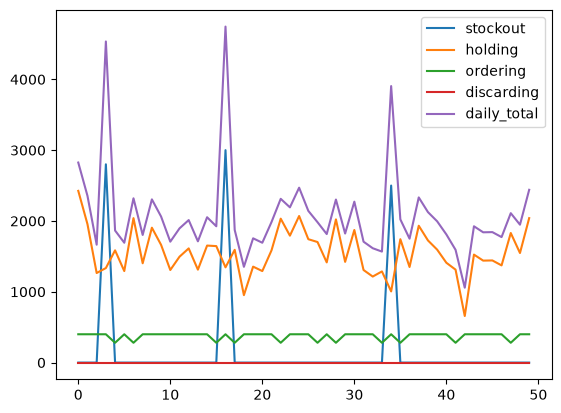

In [7]:
df[['stockout', 'holding', 'ordering', 'discarding', 'daily_total']].plot()